#1. Install Libraries

In [1]:
!pip install --force-reinstall numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
music21 9.9.2 requires numpy>=1.26.4, but you have nump

In [1]:
!pip install spectral mrmr_selection mealpy openpyxl scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.0/249.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


# 2. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             f1_score, precision_score, recall_score)
import time
from sklearn.base import clone
from sklearn.metrics import cohen_kappa_score
from sklearn.pipeline import Pipeline

from mealpy import FloatVar, PSO, GWO, MFO
from mealpy.evolutionary_based import GA

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 3. Data Loading Function & Config

## For GitHub Repository

In [2]:
def load_data(name):
    data_path = os.path.join("..", "data")
    files = {
        "IP": ("Indian_pines.mat", "indian_pines_corrected", "Indian_pines_gt.mat", "indian_pines_gt"),
        "PU": ("PaviaU.mat", "paviaU", "PaviaU_gt.mat", "paviaU_gt"),
        "SA": ("Salinas.mat", "salinas", "Salinas_gt.mat", "salinas_gt"),
    }
    df, dk, gf, gk = files[name]
    data = sio.loadmat(os.path.join(data_path, df))[dk]
    labels = sio.loadmat(os.path.join(data_path, gf))[gk]
    return data, labels

dataset    = 'IP'    # 'IP', 'PU', or 'SA'


X, y = load_data(dataset)
print(f'Data shape: {X.shape}, GT shape: {y.shape}')

Data shape: (145, 145, 200), GT shape: (145, 145)


## For colab

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def loadData(name):
    data_path = "..\\data"
    if name == 'IP':
        data   = sio.loadmat(os.path.join(data_path, 'Indian_pines.mat'))['indian_pines_corrected']
        labels = sio.loadmat(os.path.join(data_path, 'Indian_pines_gt.mat'))['indian_pines_gt']
    elif name == 'SA':
        data   = sio.loadmat(os.path.join(data_path, 'Salinas.mat'))['salinas']
        labels = sio.loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']
    elif name == 'PU':
        data   = sio.loadmat(os.path.join(data_path, 'PaviaU.mat'))['paviaU']
        labels = sio.loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))['paviaU_gt']
    else:
        raise ValueError("Dataset must be 'IP', 'PU', or 'SA'")
    return data, labels

dataset    = 'IP'    # 'IP', 'PU', or 'SA'

X, y = loadData(dataset)
print(f'Data shape: {X.shape}, GT shape: {y.shape}')

Data shape: (145, 145, 200), GT shape: (145, 145)


In [6]:
random_state = 42
train_ratio = 0.5

# Metahuristics Optimizer

In [25]:
META_METHOD = 'GA'   # 'PSO', 'GWO', 'MFO', 'GA'
META_EPOCH = 5
META_POP   = 20

X_flat_orig = X.reshape(-1, X.shape[2])  # (21025, 200)
mask = y.ravel() > 0
X_lab = X_flat_orig[mask]
y_lab = y.ravel()[mask] - 1

scaler = StandardScaler()
X_lab = scaler.fit_transform(X_lab)

def fitness(sol):
    binary = (np.array(sol) > 0.6).astype(int)
    n = int(np.sum(binary))
    if n < 3: return 0.0
    sel = np.where(binary == 1)[0]
    clf = ExtraTreesClassifier(n_estimators=20, random_state=42)
    scores = cross_val_score(clf, X_lab[:, sel], y_lab, cv=3, scoring='accuracy')
    return scores.mean() - (0.005 * n**2)

problem = {'obj_func': lambda s: -fitness(s), 'bounds': FloatVar(lb=[0]*X.shape[2], ub=[1]*X.shape[2]), 'minmax': 'min', 'log_to': None}
optimizers = {'PSO': PSO.OriginalPSO, 'GWO': GWO.OriginalGWO, 'MFO': MFO.OriginalMFO, 'GA': GA.BaseGA}
opt = optimizers[META_METHOD](epoch=META_EPOCH, pop_size=META_POP)
opt.solve(problem)

best_bin = (np.array(opt.g_best.solution) > 0.6).astype(int)
sel_idx = np.where(best_bin == 1)[0]
if len(sel_idx) < 3:
    sel_idx = np.argsort(opt.g_best.solution)[-9:]

print(f"\nSelected band using {META_METHOD}: {sel_idx}")

X_selected = X[:, :, sel_idx]
print(f"Size of Original x: {X.shape}")
print(f"Size of X_selected: {X_selected.shape}")


Selected band using GA: [  4   5   8  19  28  29  30  34  41  42  43  46  48  53  55  64  71  72
  75  81  82  91  95  97  99 100 101 103 107 111 119 122 123 133 135 141
 144 148 151 157 162 163 171 174 176 178 179 181 183 185 188]
Size of Original x: (145, 145, 200)
Size of X_selected: (145, 145, 51)


# Convert Grayscle by PCA 1 component

In [26]:
newX = np.reshape(X_selected, (-1, X_selected.shape[2]))
pca = PCA(n_components=1, random_state=random_state)
newX = pca.fit_transform(newX)
scaler = MinMaxScaler().fit(newX)
newX = scaler.transform(newX)
X_pca = np.reshape(newX, (X_selected.shape[0], X_selected.shape[1], 1))
X_pca.shape

(145, 145, 1)

# Pach window

In [27]:
def padWithZeros(X, margin=2):
    newX = np.zeros((X.shape[0] + 2*margin, X.shape[1] + 2*margin, X.shape[2]))
    newX[margin:X.shape[0]+margin, margin:X.shape[1]+margin, :] = X
    return newX

def createImageCubes(X, y, windowSize=25, removeZeroLabels=True):
    margin = int((windowSize - 1) / 2)
    zeroPaddedX = padWithZeros(X, margin=margin)
    patchesData = np.zeros((X.shape[0]*X.shape[1], windowSize, windowSize, X.shape[2]))
    patchesLabels = np.zeros((X.shape[0]*X.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0]-margin):
        for c in range(margin, zeroPaddedX.shape[1]-margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex] = patch
            patchesLabels[patchIndex] = y[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData = patchesData[patchesLabels > 0]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels


X_patches, y_patches = createImageCubes(X_pca, y, windowSize=25, removeZeroLabels=True)
X_patches = X_patches.reshape(X_patches.shape[0], -1)
X_patches.shape

(10249, 625)

# Evaluate by extratree

In [28]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    classes = np.unique(y_true)
    aa = np.mean([accuracy_score(y_true[y_true == c], y_pred[y_true == c]) for c in classes]) * 100
    return {
        'OA': round(accuracy_score(y_true, y_pred) * 100, 4),
        'AA': round(aa, 4),
        'Kappa': round(cohen_kappa_score(y_true, y_pred) * 100, 4),
        'F1': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 6),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 6),
        'Recall': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 6),
    }

In [30]:
clf = ExtraTreesClassifier(n_estimators=100, random_state=random_state)
cv_clf = clone(clf)
X_train, X_test, y_train, y_test = train_test_split(X_patches, y_patches, test_size=0.7, random_state=random_state, stratify=y_patches)

start_train = time.time()
clf.fit(X_train, y_train)
train_time = time.time() - start_train

start_test = time.time()
y_pred = clf.predict(X_test)
test_time = time.time() - start_test

metrics = compute_metrics(y_test, y_pred)
print(f"Train Time: {train_time:.2f}s Test Time: {test_time:.2f}s")
for key, val in metrics.items():
    print(f"{key} = {val:.2f}%")

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',cv_clf),
])
cross_score = cross_val_score(
    pipe, X_patches, y_patches,
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
)
print(f"CV = {cross_score.mean()*100:.2f}% OA = {metrics['OA']:.2f}%, AA = {metrics['AA']:.2f}%, Kappa = {metrics['Kappa']:.4f}")


Train Time: 2.20s Test Time: 0.46s
OA = 98.93%
AA = 96.38%
Kappa = 98.78%
F1 = 0.99%
Precision = 0.99%
Recall = 0.99%
CV = 99.94% OA = 98.93%, AA = 96.38%, Kappa = 98.7756


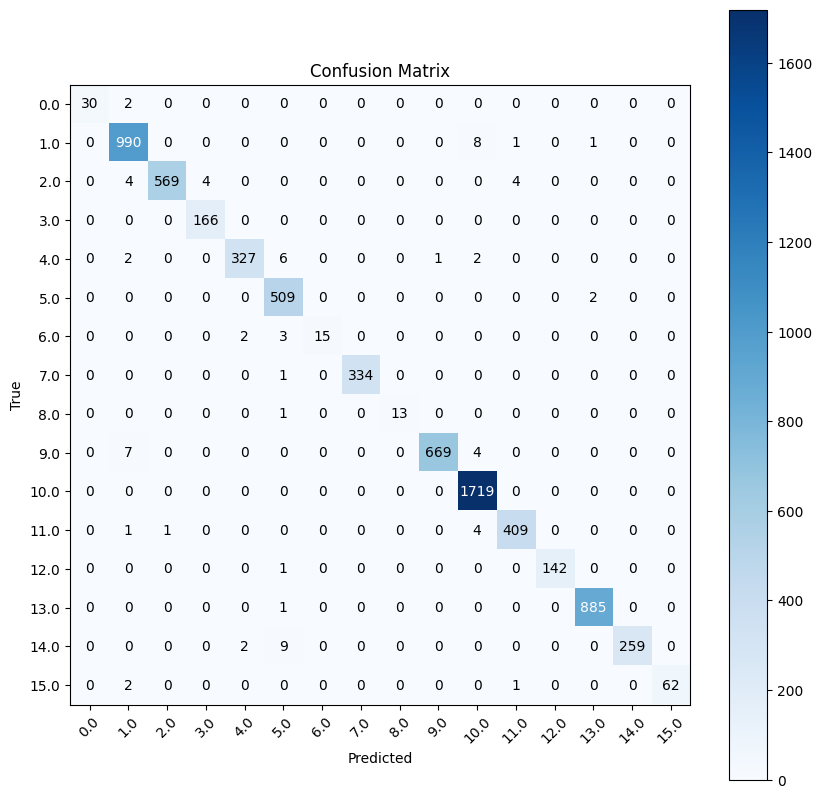

              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97        32
         1.0       0.98      0.99      0.99      1000
         2.0       1.00      0.98      0.99       581
         3.0       0.98      1.00      0.99       166
         4.0       0.99      0.97      0.98       338
         5.0       0.96      1.00      0.98       511
         6.0       1.00      0.75      0.86        20
         7.0       1.00      1.00      1.00       335
         8.0       1.00      0.93      0.96        14
         9.0       1.00      0.98      0.99       680
        10.0       0.99      1.00      0.99      1719
        11.0       0.99      0.99      0.99       415
        12.0       1.00      0.99      1.00       143
        13.0       1.00      1.00      1.00       886
        14.0       1.00      0.96      0.98       270
        15.0       1.00      0.95      0.98        65

    accuracy                           0.99      7175
   macro avg       0.99   

In [31]:
#plot confusion matrix
classes = np.unique(y_test)
plt.figure(figsize=(10, 10))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.show()
#plot classification report
cr = classification_report(y_test, y_pred)
print(cr)
